In [ ]:
# ============================================================
#  DEFINE & VERIFY KAGGLE DATASET PATH
# ============================================================
import os

# Exact path based on your dataset structure
DATASET_FOLDER = "/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease"

print("=" * 60)
print("Verifying Dataset Structure...")
print("=" * 60)

splits = ["train", "validation"]

if os.path.exists(DATASET_FOLDER):
    for split in splits:
        split_path = os.path.join(DATASET_FOLDER, split)
        if os.path.exists(split_path):
            classes = os.listdir(split_path)
            total_images = sum([len(os.listdir(os.path.join(split_path, cls))) for cls in classes])
            print(f"✅ Found '{split}' folder: {len(classes)} classes | {total_images} total images")
            if split == "train":
                print(f"   Classes identified: {classes}")
        else:
            print(f"❌ Missing '{split}' folder.")
else:
    print("❌ Dataset root path not found. Check the Kaggle input directory.")

Verifying Dataset Structure...
✅ Found 'train' folder: 6 classes | 2100 total images
   Classes identified: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'narrow_brown_spot', 'leaf_scald', 'leaf_blast']
✅ Found 'validation' folder: 6 classes | 528 total images


In [ ]:
# ============================================================
# IMPORT LIBRARIES & MLOPS TRACKING TOOLS
# ============================================================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam

# Professional Tracking Callbacks (MLOps)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard, CSVLogger
from sklearn.metrics import confusion_matrix, classification_report

print("=" * 60)
print("TensorFlow Version:", tf.__version__)
print("Professional ML Pipeline Libraries Imported.")
print("=" * 60)

TensorFlow Version: 2.20.0
Professional ML Pipeline Libraries Imported.


Visualizing Batch Images and Their Corresponding Classes...


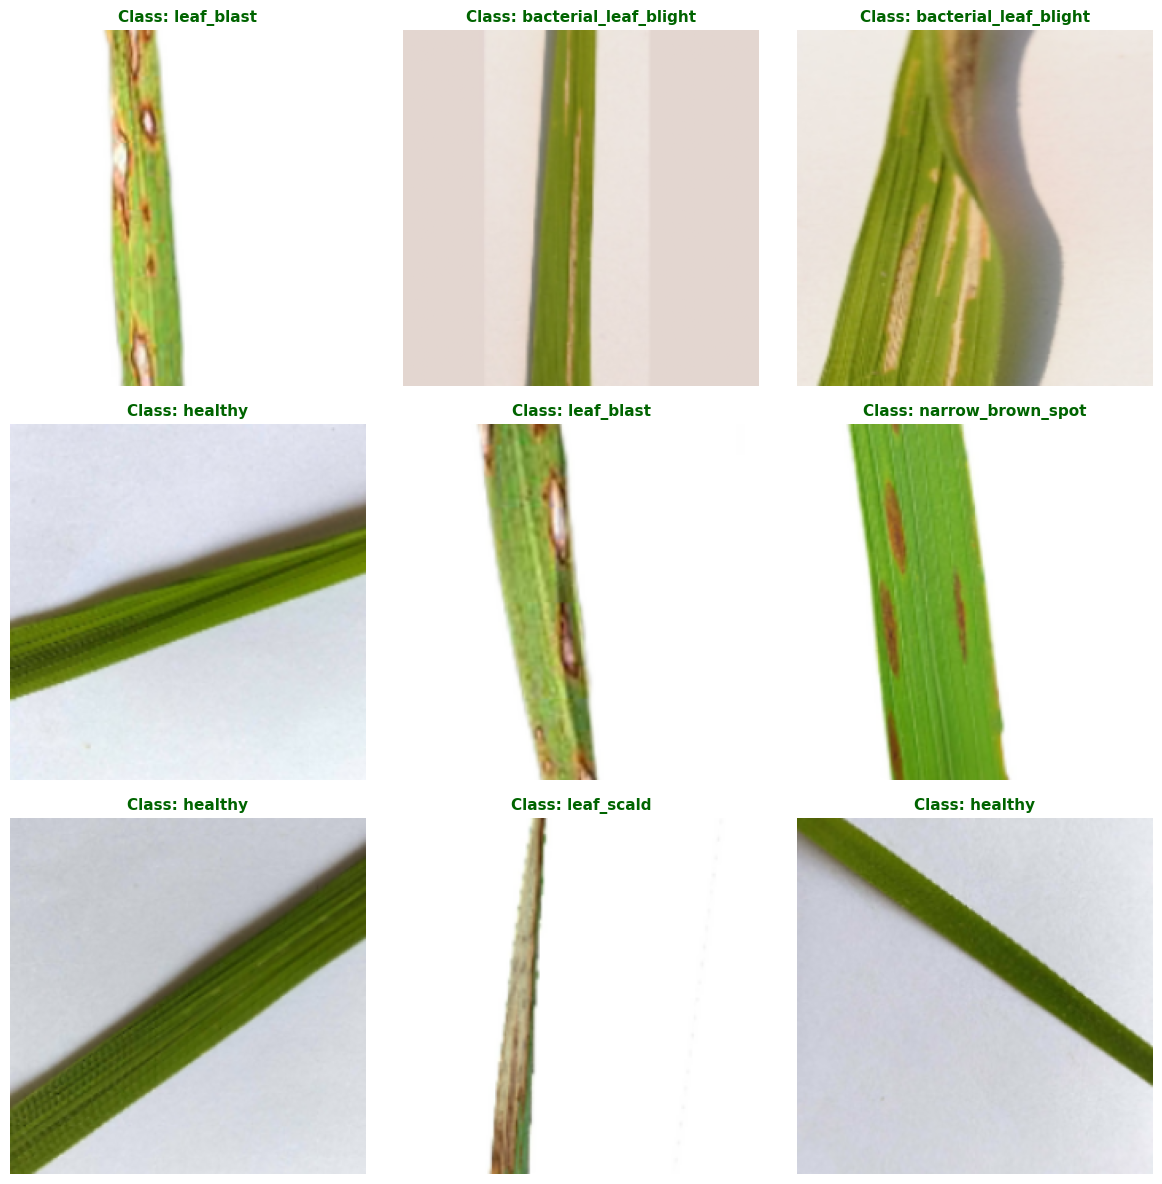

Dataset Visualization Completed Successfully!


In [ ]:
# ============================================================
# DATASET VISUALIZER (CHECK IMAGES & CLASSES)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("Visualizing Batch Images and Their Corresponding Classes...")
print("=" * 60)

# Take one batch from the training dataset
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(12, 12))
    
    # Plot first 9 images from the batch
    num_images_to_show = min(9, len(images))
    for i in range(num_images_to_show):
        ax = plt.subplot(3, 3, i + 1)
        
        # Convert tensor to numpy array
        img = images[i].numpy()
        
        # Handle pixel value scaling for proper matplotlib rendering
        if img.max() > 1.0:
            img = img / 255.0
        else:
            img = np.clip(img, 0, 1)
            
        plt.imshow(img)
        
        # Determine class index (works for both categorical one-hot and sparse labels)
        label_tensor = labels[i].numpy()
        if label_tensor.ndim > 0 and label_tensor.shape[0] > 1:
            class_idx = np.argmax(label_tensor)
        else:
            class_idx = int(label_tensor)
            
        # Display class name on top of the image
        plt.title(f"Class: {class_names[class_idx]}", fontsize=11, fontweight="bold", color="darkgreen")
        plt.axis("off")

plt.tight_layout()
plt.show()

print("=" * 60)
print("Dataset Visualization Completed Successfully!")
print("=" * 60)

In [ ]:
# ============================================================
# DATA LOADING & ADVANCED AUGMENTATION
# ============================================================

train_dir = os.path.join(DATASET_FOLDER, "train")
val_dir   = os.path.join(DATASET_FOLDER, "validation")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 6 # Adjusted based on dataset diagnostic

# Aggressive Augmentation: Crop, Zoom, and Flip to remove background bias
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomCrop(height=180, width=180), # Cut out the background edges
    tf.keras.layers.RandomZoom(height_factor=(-0.2, 0.0)), # Zoom in on the leaf
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.Resizing(IMG_SIZE[0], IMG_SIZE[1]) # Resize back to ResNet50 format
], name="advanced_augmentation")

# Load Datasets
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, label_mode='categorical'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False, label_mode='categorical'
)

class_names = train_dataset.class_names

# Apply Augmentation & Optimize Pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)

print("=" * 60)
print("Data Loading & Augmentation Pipeline Ready.")
print(f"Classes identified: {class_names}")
print("=" * 60)

Found 2100 files belonging to 6 classes.
Found 528 files belonging to 6 classes.
Data Loading & Augmentation Pipeline Ready.
Classes identified: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot']


In [ ]:
# ============================================================
# BUILD BATCH-NORMALIZED RESNET50 MODEL
# ============================================================

# 1. Initialize Base Model (ResNet50)
base_model = ResNet50(
    weights="imagenet", 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# Freeze the base model for transfer learning
base_model.trainable = False

# 2. Build Custom Classification Head (Functional API)
inputs = Input(shape=(224, 224, 3))

# Apply ResNet50's specific preprocessing (scales pixels correctly)
x = preprocess_input(inputs) 

# Pass through the frozen base model
x = base_model(x, training=False)

# Convert feature maps to a 1D vector
x = GlobalAveragePooling2D()(x)

# --- ROBUST HEAD ADDITION ---
x = BatchNormalization()(x)            # Stabilize features before Dense layer
x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)            # Stabilize features after Dense layer
x = Dropout(0.5)(x)                    # Prevent overfitting

# Output Layer for 6 Classes
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

# 3. Final Model Assembly
model = Model(inputs, outputs)

print("=" * 60)
print("Batch-Normalized ResNet50 Model Built Successfully!")
print("=" * 60)
model.summary()

Batch-Normalized ResNet50 Model Built Successfully!


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_12         │ (None, 224, 224)  │          0 │ input_layer_14[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_13         │ (None, 224, 224)  │          0 │ input_layer_14[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_14         │ (None, 224, 224)  │          0 │ input_layer_14[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_4 (Stack)     │ (None, 224, 224,  │          0 │ get_item_12[0][0… │
│                     │ 3)                │            │ get_item_13[0][0… │
│                     │                   │            │ get_item_14[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 224, 224,  │          0 │ stack_4[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_4[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 6)         │      1,542 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,123,014 (92.02 MB)

 Trainable params: 530,694 (2.02 MB)

 Non-trainable params: 23,592,320 (90.00 MB)

In [ ]:
# ============================================================
# MODEL COMPILATION & MLOPS CALLBACKS
# ============================================================

# 1. Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy", 
    metrics=["accuracy"]
)

# 2. Define Professional Callbacks (Early Stopping Removed)
callbacks = [
    # Save ONLY the best model to a file during the 30 epochs
    ModelCheckpoint(
        filepath="best_resnet50_model.keras", 
        monitor="val_accuracy", 
        save_best_only=True, 
        verbose=1
    ),
    
    # Reduce learning rate by 80% if validation loss plateaus to help model learn finer details
    ReduceLROnPlateau(
        monitor="val_loss", 
        factor=0.2, 
        patience=3, 
        min_lr=1e-6, 
        verbose=1
    ),
    
    # Log all metrics (accuracy, loss) to a CSV file for easy analysis
    CSVLogger(
        "training_history_log.csv", 
        append=True
    )
]

print("=" * 60)
print("Model Compiled and Callbacks Configured (Early Stopping Disabled)!")
print("=" * 60)

Model Compiled and Callbacks Configured (Early Stopping Disabled)!


In [ ]:
# ============================================================
# TRANSFER LEARNING TRAINING
# ============================================================

EPOCHS = 30

print("=" * 60)
print(f"Starting Transfer Learning for {EPOCHS} Epochs...")
print("=" * 60)

# Execute the training loop
history_transfer = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("=" * 60)
print("Transfer Learning Phase Completed Successfully!")
print("=" * 60)

Starting Transfer Learning for 30 Epochs...
Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.6691 - loss: 1.1100
Epoch 1: val_accuracy improved from None to 0.86364, saving model to best_resnet50_model.keras

Epoch 1: finished saving model to best_resnet50_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 347ms/step - accuracy: 0.7833 - loss: 0.6758 - val_accuracy: 0.8636 - val_loss: 0.4172 - learning_rate: 0.0010
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9029 - loss: 0.2515
Epoch 2: val_accuracy improved from 0.86364 to 0.91856, saving model to best_resnet50_model.keras

Epoch 2: finished saving model to best_resnet50_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 202ms/step - accuracy: 0.9086 - loss: 0.2509 - val_accuracy: 0.9186 - val_loss: 0.2160 - learning_rate: 0.0010
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9213 - loss: 0.2263
Epoch 3: val_accuracy improved from 0.91856 to 0.94508, saving model to best_resnet50_model.keras



Evaluating Model and Generating Predictions...
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 341ms/step

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

bacterial_leaf_blight       1.00      0.98      0.99        88
           brown_spot       0.95      0.93      0.94        88
              healthy       0.95      0.98      0.96        88
           leaf_blast       0.95      0.93      0.94        88
           leaf_scald       1.00      0.98      0.99        88
    narrow_brown_spot       0.95      1.00      0.97        88

             accuracy                           0.97       528
            macro avg       0.97      0.97      0.97       528
         weighted avg       0.97      0.97      0.97       528



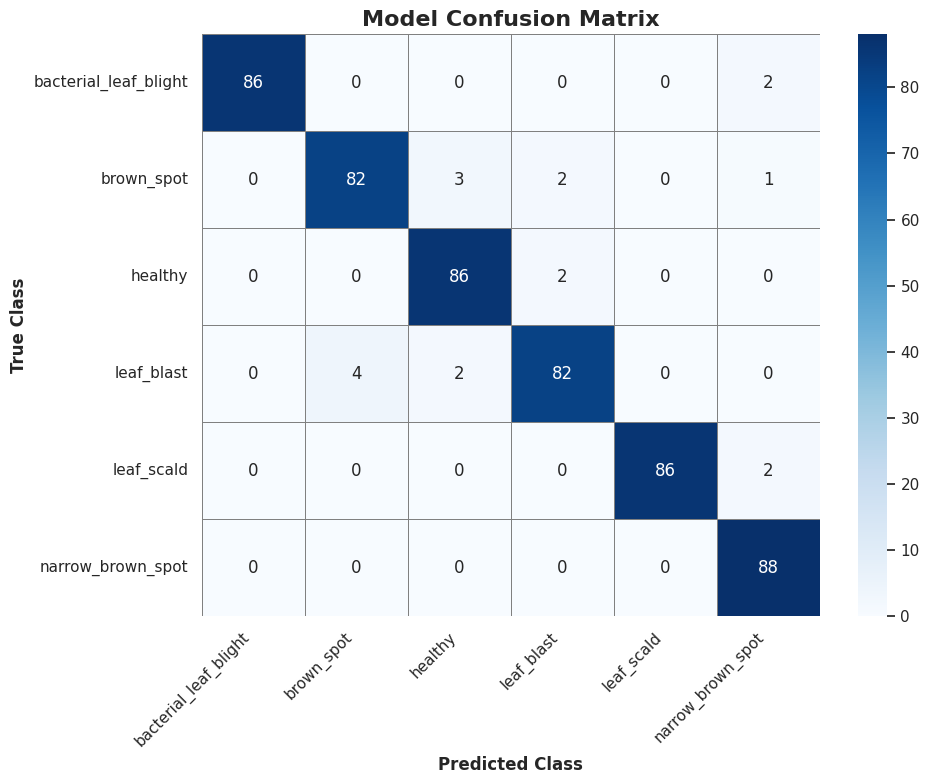

In [ ]:
# ============================================================
# CONFUSION MATRIX & CLASSIFICATION REPORT (ENHANCED)
# ============================================================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

print("="*60)
print("Evaluating Model and Generating Predictions...")
print("="*60)

# 1. Get Predictions and True Labels
predictions = model.predict(val_dataset)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.concatenate(
    [np.argmax(labels.numpy(), axis=1) for images, labels in val_dataset], 
    axis=0
)

# 2. Print Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# 3. Plot Confusion Matrix using Seaborn
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
# sns.heatmap automatically adds the text (annot=True) and formats it
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='gray')

plt.title("Model Confusion Matrix", fontsize=16, fontweight="bold")
plt.xlabel("Predicted Class", fontsize=12, fontweight="bold")
plt.ylabel("True Class", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha='right') # Rotates X labels for better readability
plt.tight_layout()
plt.show()

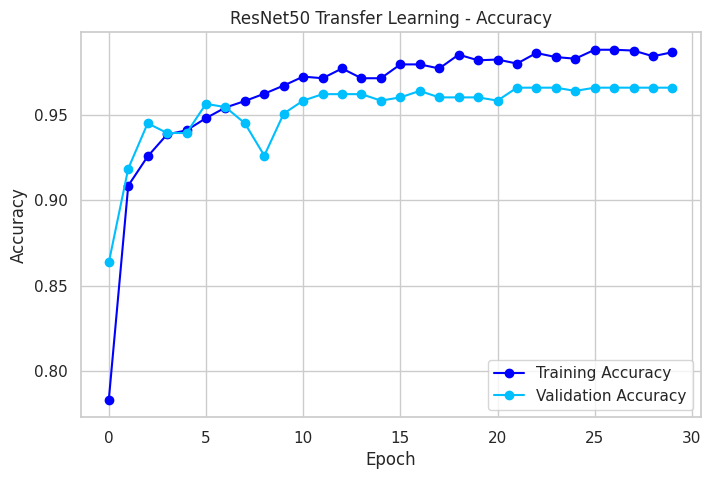

In [ ]:
# ============================================================
# PLOT TRANSFER LEARNING ACCURACY
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_transfer.history["accuracy"], marker="o", color="blue", label="Training Accuracy")
plt.plot(history_transfer.history["val_accuracy"], marker="o", color="deepskyblue", label="Validation Accuracy")

plt.title("ResNet50 Transfer Learning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

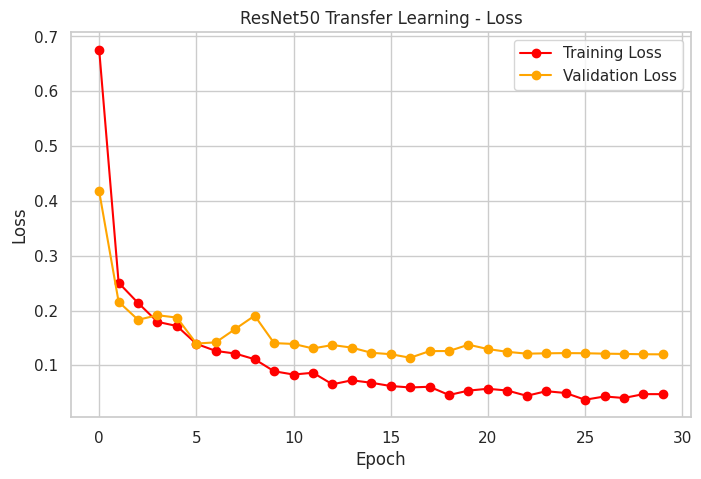

In [ ]:
# ============================================================
# PLOT TRANSFER LEARNING LOSS
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_transfer.history["loss"], marker="o", color="red", label="Training Loss")
plt.plot(history_transfer.history["val_loss"], marker="o", color="orange", label="Validation Loss")

plt.title("ResNet50 Transfer Learning - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

### Fine tune Start

In [ ]:
# ============================================================
# GRADUAL UNFREEZING & FINE-TUNING (AUTOMATED)
# ============================================================

# Blocks to unfreeze sequentially (from top to bottom)
blocks_to_unfreeze = ['conv5', 'conv4', 'conv3']
current_lr = 1e-4  # Starting fine-tuning learning rate

print("=" * 60)
print("Starting Automated Gradual Unfreezing...")
print("=" * 60)

for step, block in enumerate(blocks_to_unfreeze):
    print(f"\n--- STEP {step + 1}: Unfreezing {block} block ---")
    
    # Unfreeze the target block
    for layer in base_model.layers:
        if layer.name.startswith(block):
            layer.trainable = True
            
    # Reduce learning rate for deeper layers to prevent catastrophic forgetting
    current_lr = current_lr / 10.0 
    print(f"Recompiling with learning rate: {current_lr}")
    
    model.compile(
        optimizer=Adam(learning_rate=current_lr),
        loss="categorical_crossentropy", 
        metrics=["accuracy"]
    )
    
    # Train for a few epochs per block
    model.fit(
        train_dataset, 
        validation_data=val_dataset,
        epochs=8, # 8 epochs per block = 24 total fine-tuning epochs
        callbacks=callbacks,
        verbose=1
    )

print("=" * 60)
print("Automated Gradual Fine-Tuning Completed Successfully!")
print("=" * 60)

Starting Automated Gradual Unfreezing...

--- STEP 1: Unfreezing conv5 block ---
Recompiling with learning rate: 1e-05
Epoch 1/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.9417 - loss: 0.1997
Epoch 1: val_accuracy did not improve from 0.96591
66/66 ━━━━━━━━━━━━━━━━━━━━ 46s 387ms/step - accuracy: 0.9514 - loss: 0.1640 - val_accuracy: 0.9413 - val_loss: 0.1712 - learning_rate: 1.0000e-05
Epoch 2/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9670 - loss: 0.0867
Epoch 2: val_accuracy did not improve from 0.96591
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step - accuracy: 0.9686 - loss: 0.0867 - val_accuracy: 0.9432 - val_loss: 0.1665 - learning_rate: 1.0000e-05
Epoch 3/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9738 - loss: 0.0749
Epoch 3: val_accuracy did not improve from 0.96591

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - accuracy: 0.9724 - loss: 0.0770 - val_accuracy: 0.9621 - va

Loading Best Fine-Tuned Model for Final Evaluation...
Evaluating on Training Data...
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 177ms/step - accuracy: 0.9967 - loss: 0.0185

Evaluating on Validation Data...
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 230ms/step - accuracy: 0.9659 - loss: 0.1248

FINAL MODEL PERFORMANCE
Training Accuracy   : 99.67%  |  Training Loss   : 0.0185
Validation Accuracy : 96.59%  |  Validation Loss : 0.1248

Generating predictions on validation data...
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 338ms/step

CLASSIFICATION REPORT (Validation Data)
------------------------------------------------------------
                       precision    recall  f1-score   support

bacterial_leaf_blight       1.00      0.98      0.99        88
           brown_spot       0.96      0.93      0.95        88
              healthy       0.94      0.97      0.96        88
           leaf_blast       0.94      0.94      0.94        88
           leaf_scald       1.00      0.98      0.99        88
    narrow_brown_spo

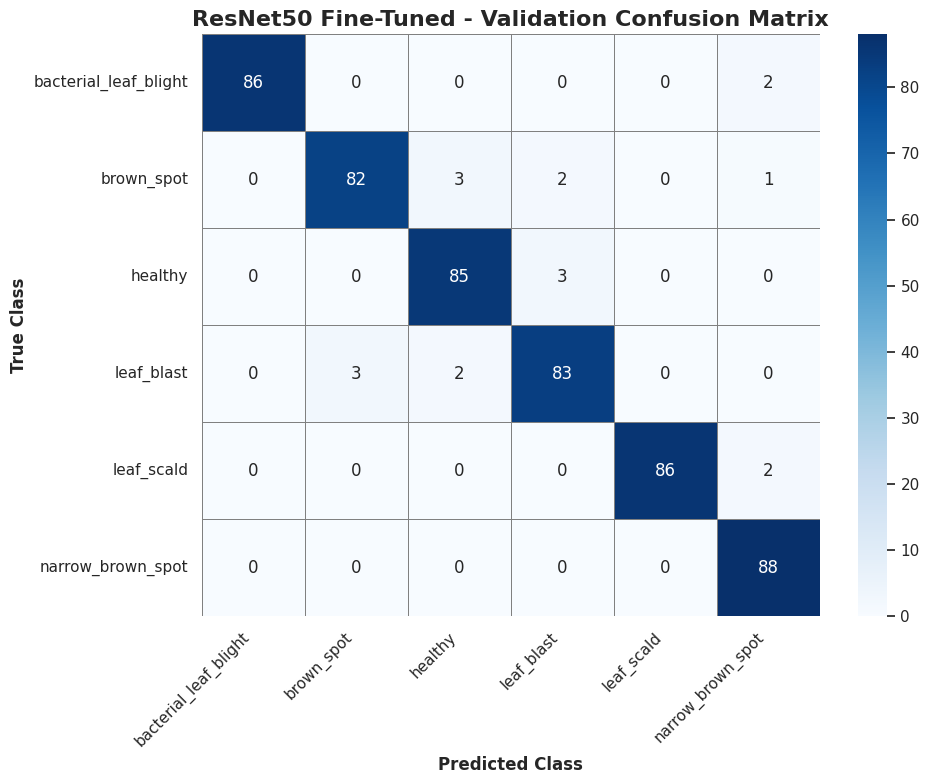

In [ ]:
# ============================================================
# FINAL EVALUATION (TRAIN vs VAL) & CONFUSION MATRIX
# ============================================================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

print("=" * 60)
print("Loading Best Fine-Tuned Model for Final Evaluation...")
print("=" * 60)

# 1. Load the absolute best model saved by ModelCheckpoint
best_model = load_model("best_resnet50_model.keras")

# 2. Evaluate on TRAINING Dataset
print("Evaluating on Training Data...")
train_loss, train_accuracy = best_model.evaluate(train_dataset, verbose=1)

# 3. Evaluate on VALIDATION Dataset
print("\nEvaluating on Validation Data...")
val_loss, val_accuracy = best_model.evaluate(val_dataset, verbose=1)

# 4. Print Comparison
print("\n" + "=" * 60)
print("FINAL MODEL PERFORMANCE")
print("=" * 60)
print(f"Training Accuracy   : {train_accuracy * 100:.2f}%  |  Training Loss   : {train_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy * 100:.2f}%  |  Validation Loss : {val_loss:.4f}")
print("=" * 60)

# 5. Get Predictions and True Labels for Confusion Matrix (on Validation Data)
print("\nGenerating predictions on validation data...")
predictions = best_model.predict(val_dataset)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.concatenate(
    [np.argmax(labels.numpy(), axis=1) for images, labels in val_dataset], 
    axis=0
)

# 6. Print Classification Report
print("\nCLASSIFICATION REPORT (Validation Data)")
print("-" * 60)
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# 7. Plot Professional Confusion Matrix using Seaborn
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='gray')

plt.title("ResNet50 Fine-Tuned - Validation Confusion Matrix", fontsize=16, fontweight="bold")
plt.xlabel("Predicted Class", fontsize=12, fontweight="bold")
plt.ylabel("True Class", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Generating Fine-Tuning Accuracy Graph...


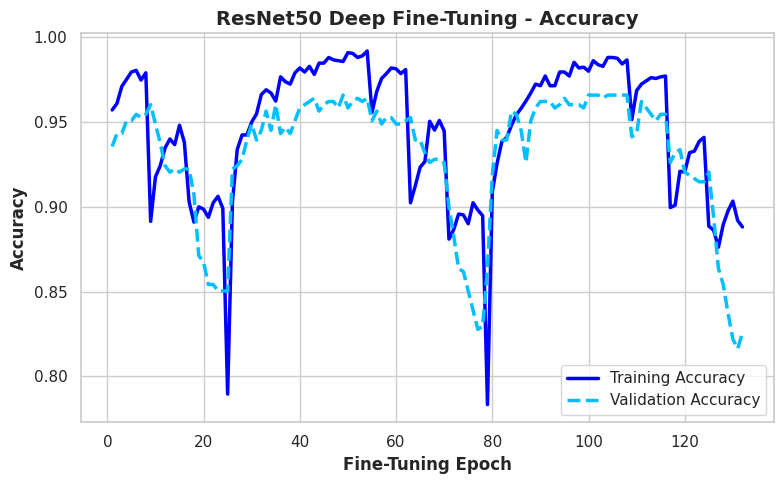

In [ ]:
# ============================================================
# FINE-TUNING ACCURACY GRAPH
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("Generating Fine-Tuning Accuracy Graph...")
print("=" * 60)

# Load the entire training history logged by CSVLogger
history_df = pd.read_csv("training_history_log.csv")

# Filter ONLY the Fine-Tuning epochs (assuming Transfer Learning was 30 epochs)
TRANSFER_LEARNING_EPOCHS = 30
finetune_df = history_df.iloc[TRANSFER_LEARNING_EPOCHS:].reset_index(drop=True)

# Set professional aesthetics
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Plot Training and Validation Accuracy
plt.plot(finetune_df.index + 1, finetune_df['accuracy'], label='Training Accuracy', linewidth=2.5, color='blue')
plt.plot(finetune_df.index + 1, finetune_df['val_accuracy'], label='Validation Accuracy', linewidth=2.5, linestyle='--', color='deepskyblue')

plt.title("ResNet50 Deep Fine-Tuning - Accuracy", fontsize=14, fontweight="bold")
plt.xlabel("Fine-Tuning Epoch", fontsize=12, fontweight="bold")
plt.ylabel("Accuracy", fontsize=12, fontweight="bold")
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

Generating Fine-Tuning Loss Graph...


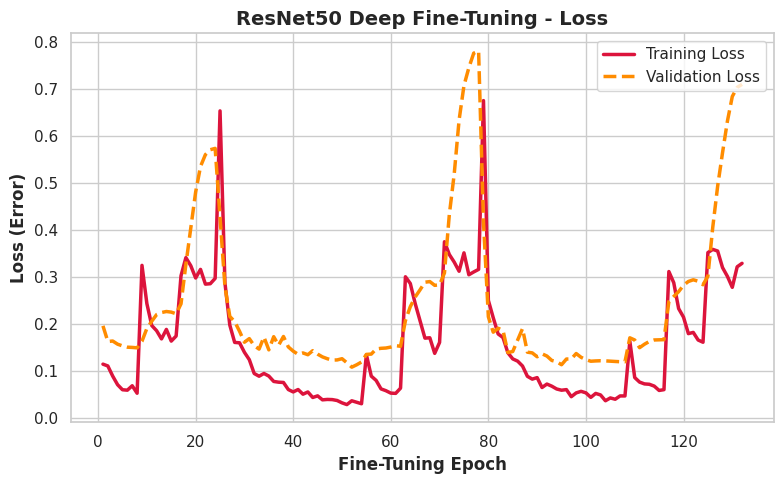

In [ ]:
# ============================================================
# FINE-TUNING LOSS GRAPH
# ============================================================

print("=" * 60)
print("Generating Fine-Tuning Loss Graph...")
print("=" * 60)

plt.figure(figsize=(8, 5))

# Plot Training and Validation Loss
plt.plot(finetune_df.index + 1, finetune_df['loss'], label='Training Loss', linewidth=2.5, color='crimson')
plt.plot(finetune_df.index + 1, finetune_df['val_loss'], label='Validation Loss', linewidth=2.5, linestyle='--', color='darkorange')

plt.title("ResNet50 Deep Fine-Tuning - Loss", fontsize=14, fontweight="bold")
plt.xlabel("Fine-Tuning Epoch", fontsize=12, fontweight="bold")
plt.ylabel("Loss (Error)", fontsize=12, fontweight="bold")
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

Loading continuous training log for Accuracy Comparison...


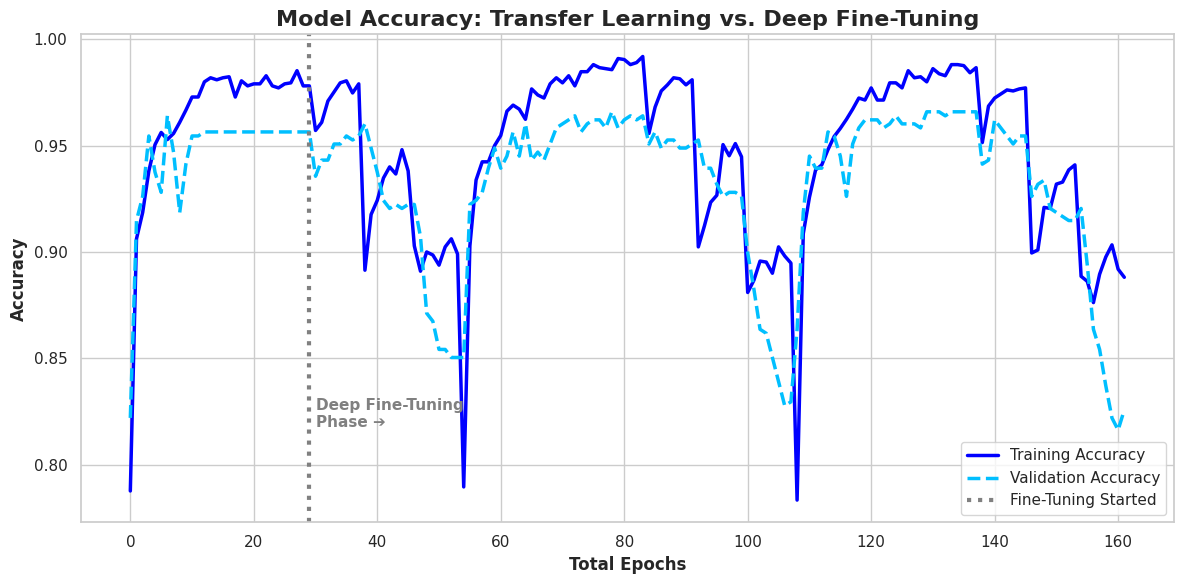

In [ ]:
# ============================================================
# ACCURACY COMPARISON (BEFORE & AFTER FINE-TUNING)
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("Loading continuous training log for Accuracy Comparison...")
print("=" * 60)

# Load the entire training history logged by CSVLogger
history_df = pd.read_csv("training_history_log.csv")

# Set professional aesthetics
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Plot Training and Validation Accuracy
plt.plot(history_df.index, history_df['accuracy'], label='Training Accuracy', linewidth=2.5, color='blue')
plt.plot(history_df.index, history_df['val_accuracy'], label='Validation Accuracy', linewidth=2.5, linestyle='--', color='deepskyblue')

# Add a vertical marker where Transfer Learning ended and Fine-Tuning began
# (Assuming Transfer Learning ran for 30 epochs, so index 29 is the transition)
TRANSFER_LEARNING_EPOCHS = 30
if len(history_df) > TRANSFER_LEARNING_EPOCHS:
    plt.axvline(x=TRANSFER_LEARNING_EPOCHS - 1, color='gray', linestyle=':', linewidth=3, label='Fine-Tuning Started')
    # Add text annotation
    plt.text(TRANSFER_LEARNING_EPOCHS, history_df['val_accuracy'].min(), 'Deep Fine-Tuning\nPhase ➔', 
             color='gray', fontsize=11, fontweight='bold', va='bottom')

plt.title("Model Accuracy: Transfer Learning vs. Deep Fine-Tuning", fontsize=16, fontweight="bold")
plt.xlabel("Total Epochs", fontsize=12, fontweight="bold")
plt.ylabel("Accuracy", fontsize=12, fontweight="bold")
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

In [88]:
# ==========================================
# SAVE TRAINED RESNET50 MODEL
# ==========================================
MODEL_SAVE_PATH = 'best_resnet50_model.keras'

# Save the entire model (architecture, weights, and training configuration)
model.save(MODEL_SAVE_PATH)

print(f"✅ Model successfully saved at: {MODEL_SAVE_PATH}")

✅ Model successfully saved at: best_resnet50_model.keras


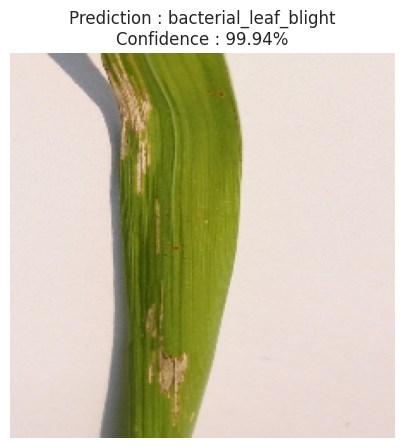

Predicted Class : bacterial_leaf_blight
Confidence      : 99.94%

All Class Probabilities:

bacterial_leaf_blight     : 99.94%
brown_spot                : 0.05%
healthy                   : 0.01%
leaf_blast                : 0.00%
leaf_scald                : 0.00%
narrow_brown_spot         : 0.00%


In [103]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# ==========================
# Load Model
# ==========================
model = tf.keras.models.load_model("best_resnet50_model.keras")

# ==========================
# Class Names
# IMPORTANT: Order should be same as training
# ==========================
class_names = [
    "bacterial_leaf_blight",
    "brown_spot",
    "healthy",
    "leaf_blast",
    "leaf_scald",
    "narrow_brown_spot"
]

# ==========================
# IMAGE PATH
# ==========================
img_path = "/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease/validation/bacterial_leaf_blight/bacterial_val (13).JPG"   # <-- Change this

# ==========================
# Read Image
# ==========================
img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

# ==========================
# Prediction
# ==========================
prediction = model.predict(img_array, verbose=0)

pred_idx = np.argmax(prediction)

confidence = prediction[0][pred_idx] * 100

# ==========================
# Display
# ==========================
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction : {class_names[pred_idx]}\nConfidence : {confidence:.2f}%"
)

plt.show()

print("="*50)
print("Predicted Class :", class_names[pred_idx])
print("Confidence      : {:.2f}%".format(confidence))
print("="*50)

print("\nAll Class Probabilities:\n")

for i, cls in enumerate(class_names):
    print(f"{cls:25s} : {prediction[0][i]*100:.2f}%")